# Group04 — SOMLAP — Track 3, Task 2
## CNN baselines

**Authors:** Md. Rafiqul Islam (2026-2-74-025); Ahanaf Shahadat Taseen (2026-2-74-033); Reasad Mahmood (2026-2-74-012).

Four representative baselines are evaluated on one fixed, leakage-aware test set:
a custom plain CNN, VGG16, ResNet50 and EfficientNetB0. Exact duplicate feature
vectors are grouped before splitting. Preprocessing is fitted on training data only;
augmentation and class weights are applied only during training. Every training call
uses a maximum of **60 epochs** with early stopping.

Macro-F1 is the primary selection metric. The evaluation also reports per-class
precision, recall and F1, macro and weighted averages, confusion matrices, ROC-AUC,
PR-AUC, training time, inference time, parameter count and serialized model size.


In [1]:
# ==========================================================
#Task 2 CNN Baselines

print("baseline notebook")


baseline notebook


In [2]:
# ==========================================================
# CELL 1
# Import Required Libraries
# ==========================================================

import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)


Libraries Imported Successfully


In [3]:
# ==========================================================
# CELL 2 — Kaggle GPU Initialization
# ==========================================================

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "No GPU detected. In Kaggle Settings, select GPU T4 x2 or GPU P100, "
        "start a fresh session, and run from Cell 0."
    )

# Must be configured before TensorFlow initializes the GPU devices.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

# Use both T4 GPUs when Kaggle provides T4 x2. This becomes a one-device
# strategy automatically when only one GPU (for example P100) is available.
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.OneDeviceStrategy(device="/GPU:0")

NUM_REPLICAS = strategy.num_replicas_in_sync
# Keep the global batch at 32 to match Ahnaf's original/proposed-model run.
BATCH_SIZE = 32
PER_REPLICA_BATCH_SIZE = BATCH_SIZE // NUM_REPLICAS

print("GPU initialization successful")
print("Physical GPUs:", len(gpus))
print("Strategy:", type(strategy).__name__)
print("Synchronized replicas:", NUM_REPLICAS)
print("Per-replica batch size:", PER_REPLICA_BATCH_SIZE)
print("Global batch size:", BATCH_SIZE)


# Shared maximum for every model. Early stopping may finish before epoch 60.
EPOCHS = 60
print("Maximum epochs per model:", EPOCHS)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPU initialization successful
Physical GPUs: 2
Strategy: MirroredStrategy
Synchronized replicas: 2
Per-replica batch size: 16
Global batch size: 32
Maximum epochs per model: 60


I0000 00:00:1787875546.764549      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787875546.767696      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# ==========================================================
# CELL 3
# Load Dataset
# ==========================================================

DATA_PATH = "/kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv"

df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

display(df.head())

Dataset Loaded Successfully
Shape : (51408, 109)


,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,...,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class
0,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
1,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
2,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
3,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
4,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0


In [5]:
# ==========================================================
# CELL 4
# Features and Target
# ==========================================================

TARGET = "class"

X = df.drop(columns=[TARGET])

y = df[TARGET]

print("="*60)
print("Dataset Information")
print("="*60)

print("Features :", X.shape[1])

print("Samples :", len(df))

print("Classes :", sorted(y.unique()))

print("\nClass Distribution")

display(y.value_counts())

Dataset Information
Features : 108
Samples : 51408
Classes : [np.int64(0), np.int64(1)]

Class Distribution


class
0    31600
1    19808
Name: count, dtype: int64

In [6]:
# ==========================================================
# CELL 5
# Leakage-Aware 70/15/15 Train/Validation/Test Split
# ==========================================================

# Exact duplicate feature vectors are assigned to one group so an identical
# sample can never appear on both sides of the split.
feature_group = pd.util.hash_pandas_object(X, index=False).astype("uint64")
group_table = pd.DataFrame({"group": feature_group, "class": y})

# An identical feature vector must not have conflicting labels.
group_label_counts = group_table.groupby("group")["class"].nunique()
if int((group_label_counts > 1).sum()) != 0:
    raise ValueError("Identical feature vectors with conflicting labels were found.")

unique_groups = group_table.drop_duplicates("group")
train_groups, temp_groups = train_test_split(
    unique_groups,
    test_size=0.30,
    random_state=SEED,
    stratify=unique_groups["class"]
)
valid_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_groups["class"]
)

train_group_ids = set(train_groups["group"])
valid_group_ids = set(valid_groups["group"])
test_group_ids = set(test_groups["group"])

train_mask = feature_group.isin(train_group_ids)
valid_mask = feature_group.isin(valid_group_ids)
test_mask = feature_group.isin(test_group_ids)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

assert not (train_group_ids & valid_group_ids)
assert not (train_group_ids & test_group_ids)
assert not (valid_group_ids & test_group_ids)
assert len(X_train) + len(X_valid) + len(X_test) == len(X)

duplicate_rows = len(X) - feature_group.nunique()
summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Samples": [len(X_train), len(X_valid), len(X_test)],
    "Unique feature groups": [
        len(train_group_ids), len(valid_group_ids), len(test_group_ids)
    ],
    "Class-1 percentage": [
        100 * y_train.mean(), 100 * y_valid.mean(), 100 * y_test.mean()
    ]
})

print("Exact duplicate rows grouped before splitting:", duplicate_rows)
print("Feature-group overlap across splits: 0")
display(summary)


Exact duplicate rows grouped before splitting: 14367
Feature-group overlap across splits: 0


,Dataset,Samples,Unique feature groups,Class-1 percentage
0,Training,36027,25928,38.634913
1,Validation,7651,5556,38.060384
2,Testing,7730,5557,38.512290


In [7]:
# ==========================================================
# CELL 6
# Standardization
# ==========================================================

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_valid_std = scaler.transform(X_valid)

X_test_std = scaler.transform(X_test)

print("="*60)
print("Standardization Completed")
print("="*60)

print("Training Mean :", round(X_train_std.mean(),4))

print("Training Std  :", round(X_train_std.std(),4))

Standardization Completed
Training Mean : -0.0
Training Std  : 1.0


In [8]:
# ==========================================================
# CELL 7
# Pixel Scaling to [0, 255] Using Training Data Only
# ==========================================================

pixel_scaler = MinMaxScaler(feature_range=(0, 255))
X_train_pixel = pixel_scaler.fit_transform(X_train_std)
X_valid_pixel = pixel_scaler.transform(X_valid_std)
X_test_pixel = pixel_scaler.transform(X_test_std)

# Unseen validation/test extrema can fall outside the fitted training range.
# Clip before uint8 conversion to prevent wrap-around artifacts.
X_train_pixel = np.clip(X_train_pixel, 0, 255).astype(np.uint8)
X_valid_pixel = np.clip(X_valid_pixel, 0, 255).astype(np.uint8)
X_test_pixel = np.clip(X_test_pixel, 0, 255).astype(np.uint8)

print("Pixel scaling completed")
print("Train shape:", X_train_pixel.shape)
print("Train range:", X_train_pixel.min(), "to", X_train_pixel.max())
print("Validation range:", X_valid_pixel.min(), "to", X_valid_pixel.max())
print("Test range:", X_test_pixel.min(), "to", X_test_pixel.max())


Pixel scaling completed
Train shape: (36027, 108)
Train range: 0 to 255
Validation range: 0 to 255
Test range: 0 to 255


In [9]:
# ==========================================================
# CELL 8
# Convert Feature Vector to 12×9 Image
# ==========================================================

IMG_H = 12
IMG_W = 9

X_train_img = X_train_pixel.reshape(-1, IMG_H, IMG_W)
X_valid_img = X_valid_pixel.reshape(-1, IMG_H, IMG_W)
X_test_img  = X_test_pixel.reshape(-1, IMG_H, IMG_W)

print("="*60)
print("12×9 Image Conversion Completed")
print("="*60)

print("Train :", X_train_img.shape)
print("Validation :", X_valid_img.shape)
print("Test :", X_test_img.shape)

12×9 Image Conversion Completed
Train : (36027, 12, 9)
Validation : (7651, 12, 9)
Test : (7730, 12, 9)


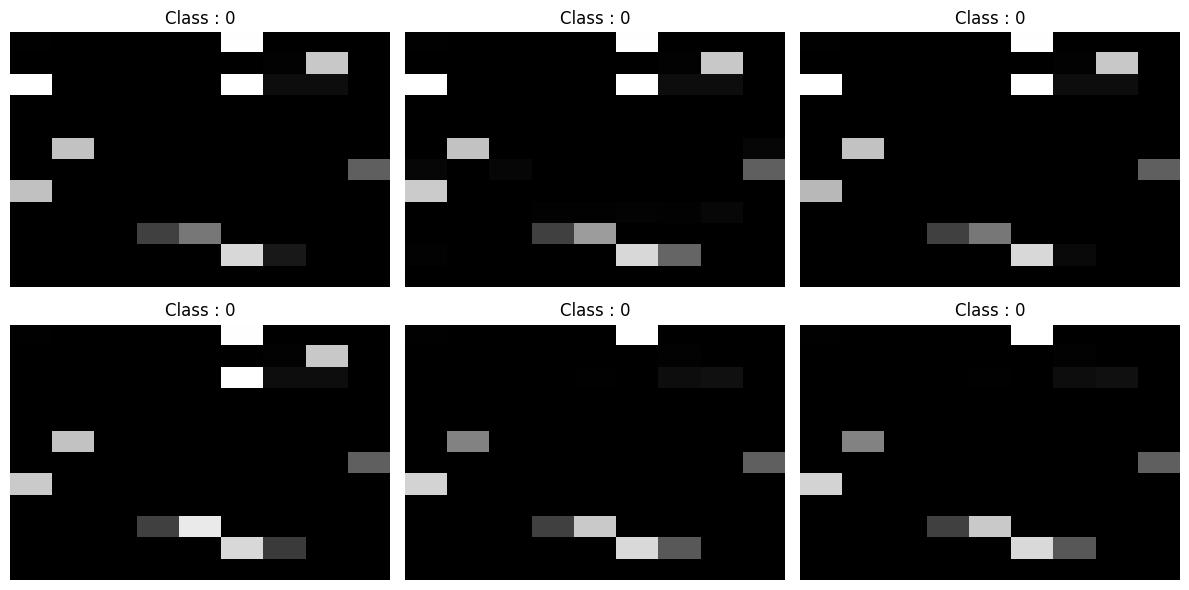

In [10]:
# ==========================================================
# CELL 9
# Visualize Generated Images
# ==========================================================

plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        X_train_img[i],
        cmap="gray",
        aspect="auto"
    )

    plt.title(f"Class : {y_train.iloc[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [11]:
# ==========================================================
# CELL 10
# TensorFlow Datasets + Position-Preserving Augmentation
# ==========================================================

IMG_SIZE = 96
AUTOTUNE = tf.data.AUTOTUNE
AUGMENT_NOISE_STD = 1.5


def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Geometric flips/rotations would move named SOMLAP features to incorrect
    # grid positions. Mild intensity noise preserves feature locations.
    noise = tf.random.normal(tf.shape(image), stddev=AUGMENT_NOISE_STD)
    image = tf.clip_by_value(image + noise, 0.0, 255.0)
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)


def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)


train_ds = tf.data.Dataset.from_tensor_slices((X_train_img, y_train.values))
valid_ds = tf.data.Dataset.from_tensor_slices((X_valid_img, y_valid.values))
test_ds = tf.data.Dataset.from_tensor_slices((X_test_img, y_test.values))

train_ds = (train_ds.shuffle(min(10000, len(X_train)), seed=SEED,
                             reshuffle_each_iteration=True)
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))
valid_ds = (valid_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds = (test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print("GPU datasets created")
print("Global batch size:", BATCH_SIZE)
print("Training augmentation: Gaussian intensity noise, std =", AUGMENT_NOISE_STD)
print("Validation/test augmentation: none")


GPU datasets created
Global batch size: 32
Training augmentation: Gaussian intensity noise, std = 1.5
Validation/test augmentation: none


**Reading:** The split preserves class proportions while keeping every exact duplicate feature group entirely within one partition; reported overlap is zero.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.79631].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.69507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..251.43942].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..251.38008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.0039].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.48561].


Batch Shape
Images : (32, 96, 96, 3)
Labels : (32,)


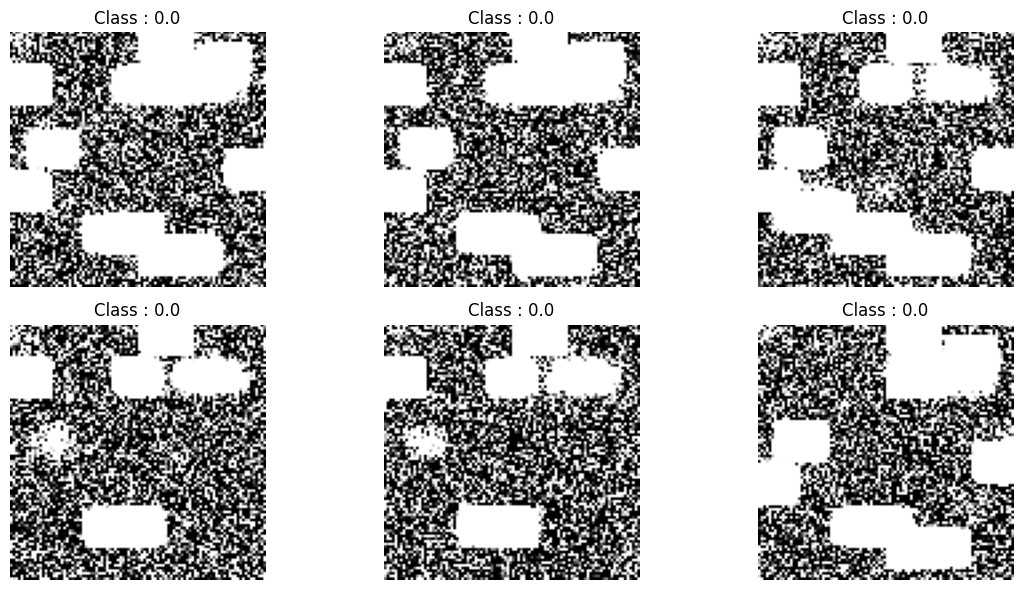

In [12]:
# ==========================================================
# CELL 11
# Verify Dataset
# ==========================================================

for images, labels in train_ds.take(1):

    print("="*60)
    print("Batch Shape")
    print("="*60)

    print("Images :", images.shape)
    print("Labels :", labels.shape)

    plt.figure(figsize=(12,6))

    for i in range(6):

        plt.subplot(2,3,i+1)

        plt.imshow(images[i])

        plt.title(f"Class : {labels[i].numpy()}")

        plt.axis("off")

    plt.tight_layout()

    plt.show()

In [13]:
# ==========================================================
# CELL 12
# Compute Class Weights
# ==========================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("="*60)
print("Class Weights")
print("="*60)

print(class_weights)

Class Weights
{np.int64(0): np.float64(0.8147955491224896), np.int64(1): np.float64(1.294166247575257)}


**Reading:** Scaling and reshaping create fixed 12×9 feature grids; resizing to 96×96×3 supports the CNN APIs but does not create natural spatial meaning.


In [14]:
# ==========================================================
# CELL 13
# Model and Evaluation Imports
# ==========================================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, Activation,
    Dense, Dropout, GlobalAveragePooling2D, Rescaling
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print("Model libraries imported successfully")


Model libraries imported successfully


In [15]:
# ==========================================================
# CELL 14
# VGG16 Baseline Model
# ==========================================================

with strategy.scope():
    base_model = VGG16(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = vgg16_preprocess(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.50)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    vgg16_model = Model(inputs, outputs, name="VGG16_baseline")
    vgg16_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# ==========================================================
# CELL 15
# Compile Model
# ==========================================================

with strategy.scope():
    vgg16_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),

        loss="binary_crossentropy",
        run_eagerly=False,

        metrics=[

            "accuracy",

            tf.keras.metrics.Precision(),

            tf.keras.metrics.Recall()

        ]

    )

    print("="*60)
    print("Model Compiled Successfully")
    print("="*60)


Model Compiled Successfully


In [17]:
# ==========================================================
# CELL 16
# Fresh Training Callbacks for Each Model
# ==========================================================

def make_callbacks(model_slug):
    return [
        EarlyStopping(
            monitor="val_loss", patience=10,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4,
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f"Group04_SOMLAP_{model_slug}_best.keras",
            monitor="val_loss", save_best_only=True, verbose=0
        )
    ]

print("Callbacks: EarlyStopping(10), ReduceLR(4), best-model checkpoint")


Callbacks: EarlyStopping(10), ReduceLR(4), best-model checkpoint


In [18]:
# ==========================================================
# CELL 17
# Train VGG16
# ==========================================================

start_train = time.time()

history_vgg = vgg16_model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=make_callbacks("vgg16"),

    verbose=1

)

training_time_vgg = time.time() - start_train

print("="*60)
print("Training Finished")
print("="*60)

print(f"Training Time : {training_time_vgg:.2f} sec")


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [19]:
# ==========================================================
# CELL 18
# VGG16 Test Prediction
# ==========================================================

start = time.time()
y_prob = vgg16_model.predict(test_ds, verbose=0).ravel()
inference_time = time.time() - start
y_pred = (y_prob >= 0.5).astype(int)

print("VGG16 prediction completed")
print("Inference Time:", round(inference_time, 4), "sec")


VGG16 prediction completed
Inference Time: 6.2814 sec


In [20]:
# ==========================================================
# CELL 19
# VGG16 Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

display(pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score",
                                         "Macro F1", "Weighted F1", "ROC AUC", "PR AUC"],
                      "Value": [accuracy, precision, recall, f1, f1_macro,
                                f1_weighted, auc, pr_auc]}))


,Metric,Value
0,Accuracy,0.900906
1,Precision,0.797257
2,Recall,0.995969
3,F1 Score,0.885603
4,Macro F1,0.899100
5,Weighted F1,0.902201
6,ROC AUC,0.994977
7,PR AUC,0.992493


In [21]:
# ==========================================================
# CELL 20
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9970    0.8414    0.9126      4753
           1     0.7973    0.9960    0.8856      2977

    accuracy                         0.9009      7730
   macro avg     0.8971    0.9187    0.8991      7730
weighted avg     0.9201    0.9009    0.9022      7730



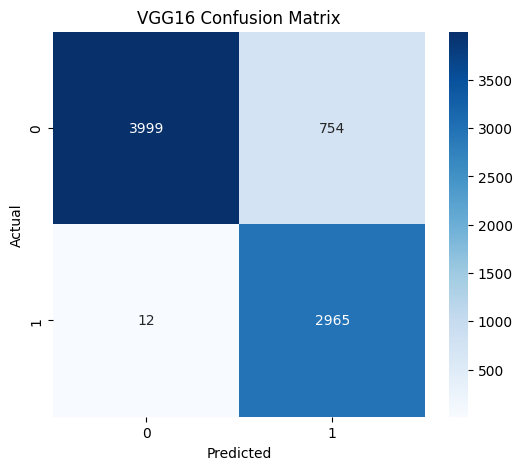

In [22]:
# ==========================================================
# CELL 21
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("VGG16 Confusion Matrix")

plt.show()

In [23]:
# ==========================================================
# CELL 22
# VGG16 Model Information (actual saved size)
# ==========================================================

parameters = vgg16_model.count_params()
_size_path = "_vgg16_size_check.keras"
vgg16_model.save(_size_path, overwrite=True)
size_mb = os.path.getsize(_size_path) / (1024 ** 2)
os.remove(_size_path)

print("Parameters:", format(parameters, ","))
print("Training Time:", round(training_time_vgg, 2), "sec")
print("Inference Time:", round(inference_time, 4), "sec")
print("Actual Model Size:", round(size_mb, 2), "MB")


Parameters: 14,846,273
Training Time: 519.98 sec
Inference Time: 6.2814 sec
Actual Model Size: 57.73 MB


**Reading:** VGG16 reaches very high malware recall but lower precision, producing many false positives and a lower Macro-F1 than the plain CNN.


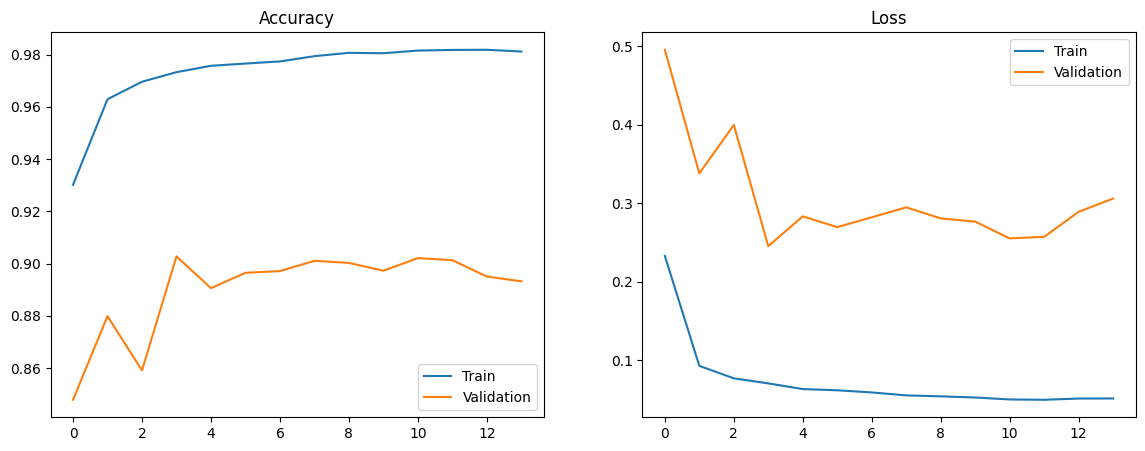

In [24]:
# ==========================================================
# CELL 23
# Accuracy & Loss Curves
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history_vgg.history["accuracy"],label="Train")

plt.plot(history_vgg.history["val_accuracy"],label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history_vgg.history["loss"],label="Train")

plt.plot(history_vgg.history["val_loss"],label="Validation")

plt.title("Loss")

plt.legend()

plt.show()

In [25]:
accuracy_vgg = accuracy
precision_vgg = precision
recall_vgg = recall
f1_vgg = f1
f1_macro_vgg = f1_macro
f1_weighted_vgg = f1_weighted
auc_vgg = auc
pr_auc_vgg = pr_auc
inference_time_vgg = inference_time
parameters_vgg = parameters
size_mb_vgg = size_mb

y_prob_vgg = y_prob.copy()
y_pred_vgg = y_pred.copy()


**Reading:** The VGG16 curves show strong ranking performance despite its weaker fixed-threshold classification; threshold choice materially changes the precision–recall trade-off.


## ResNet50 baseline


In [26]:
# ==========================================================
# CELL 24
# Import ResNet50
# ==========================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D


In [27]:
# ==========================================================
# CELL 25
# Build ResNet50
# ==========================================================

with strategy.scope():
    base_model = ResNet50(weights="imagenet", include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = resnet50_preprocess(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.40)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    resnet_model = Model(inputs, outputs, name="ResNet50_baseline")
    resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 96, 96, 3) │          0 │ get_item_3[0][0], │
│                     │                   │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96, 96, 3) │          0 │ stack_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 3, 3,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
# ==========================================================
# CELL 26
# Compile
# ==========================================================

with strategy.scope():
    resnet_model.compile(

        optimizer=tf.keras.optimizers.Adam(1e-4),

        loss="binary_crossentropy",
        run_eagerly=False,

        metrics=[

            "accuracy",

            tf.keras.metrics.Precision(),

            tf.keras.metrics.Recall()

        ]

    )


In [29]:
# ==========================================================
# CELL 27
# Train
# ==========================================================

start = time.time()

history_resnet = resnet_model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=make_callbacks("resnet50"),

    verbose=1

)

training_time_resnet = time.time() - start

print("="*60)

print("Training Finished")

print("="*60)

print("Training Time :",round(training_time_resnet,2),"sec")


Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.9565 - loss: 0.1089 - precision_1: 0.9277 - recall_1: 0.9624 - val_accuracy: 0.9209 - val_loss: 0.1790 - val_precision_1: 0.8457 - val_recall_1: 0.9691 - learning_rate: 1.0000e-04
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.9715 - loss: 0.0733 - precision_1: 0.9510 - recall_1: 0.9766 - val_accuracy: 0.9174 - val_loss: 0.1729 - val_precision_1: 0.8379 - val_recall_1: 0.9708 - learning_rate: 1.0000e-04
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.9726 - loss: 0.0676 - precision_1: 0.9534 - recall_1: 0.9769 - val_accuracy: 0.9118 - val_loss: 0.1794 - val_precision_1: 0.8235 - val_recall_1: 0.9777 - learning_rate: 1.0000e-04
Epoch 4/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.9746 - loss: 0.0635 

In [30]:
# ==========================================================
# ResNet50 Test Evaluation
# ==========================================================

start = time.time()
y_prob_resnet = resnet_model.predict(test_ds, verbose=0).ravel()
inference_time_resnet = time.time() - start
y_pred_resnet = (y_prob_resnet >= 0.5).astype(int)

accuracy_resnet = accuracy_score(y_test, y_pred_resnet)
precision_resnet = precision_score(y_test, y_pred_resnet, zero_division=0)
recall_resnet = recall_score(y_test, y_pred_resnet, zero_division=0)
f1_resnet = f1_score(y_test, y_pred_resnet, zero_division=0)
f1_macro_resnet = f1_score(y_test, y_pred_resnet, average="macro", zero_division=0)
f1_weighted_resnet = f1_score(y_test, y_pred_resnet, average="weighted", zero_division=0)
auc_resnet = roc_auc_score(y_test, y_prob_resnet)
pr_auc_resnet = average_precision_score(y_test, y_prob_resnet)

parameters_resnet = resnet_model.count_params()
_size_path = "_resnet50_size_check.keras"
resnet_model.save(_size_path, overwrite=True)
size_mb_resnet = os.path.getsize(_size_path) / (1024 ** 2)
os.remove(_size_path)

print(classification_report(y_test, y_pred_resnet, digits=4, zero_division=0))
display(pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score",
                                         "Macro F1", "Weighted F1", "ROC AUC", "PR AUC"],
                      "Value": [accuracy_resnet, precision_resnet, recall_resnet,
                                f1_resnet, f1_macro_resnet, f1_weighted_resnet,
                                auc_resnet, pr_auc_resnet]}))


              precision    recall  f1-score   support

           0     0.9793    0.8965    0.9361      4753
           1     0.8544    0.9698    0.9084      2977

    accuracy                         0.9247      7730
   macro avg     0.9169    0.9331    0.9223      7730
weighted avg     0.9312    0.9247    0.9254      7730



,Metric,Value
0,Accuracy,0.924709
1,Precision,0.854395
2,Recall,0.969768
3,F1 Score,0.908433
4,Macro F1,0.922253
5,Weighted F1,0.925428
6,ROC AUC,0.987535
7,PR AUC,0.982228


In [31]:
from tensorflow.keras.applications import EfficientNetB0

# EfficientNetB0 in current tf.keras includes its own input Rescaling layer.
# Feed it raw float32 pixels in [0, 255]; do not apply preprocess_input again.


In [32]:
# ==========================================================
# EfficientNetB0 Baseline
# ==========================================================

with strategy.scope():
    base_model = EfficientNetB0(weights="imagenet", include_top=False,
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.40)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    efficientnet_model = Model(inputs, outputs, name="EfficientNetB0_baseline")
    efficientnet_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [33]:


with strategy.scope():
    efficientnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        run_eagerly=False,
        metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )


In [34]:
# Fresh callbacks are created by make_callbacks() for each model.


In [35]:
start_train = time.time()

history_efficient = efficientnet_model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=make_callbacks("efficientnetb0")

)

training_time_efficient = time.time() - start_train

print("="*60)
print("Training Finished")
print("="*60)
print("Training Time :", round(training_time_efficient,2),"sec")


Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1787876580.866902      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1126/1126 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.8250 - loss: 0.3636 - precision: 0.7160 - recall: 0.9067 - val_accuracy: 0.5645 - val_loss: 0.6321 - val_precision: 0.4661 - val_recall: 0.9918 - learning_rate: 1.0000e-04
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.8770 - loss: 0.2876 - precision: 0.7934 - recall: 0.9216 - val_accuracy: 0.8650 - val_loss: 0.4869 - val_precision: 0.7658 - val_recall: 0.9296 - learning_rate: 1.0000e-04
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.9023 - loss: 0.2539 - precision: 0.8382 - recall: 0.9257 - val_accuracy: 0.9080 - val_loss: 0.4258 - val_precision: 0.8923 - val_recall: 0.8623 - learning_rate: 1.0000e-04
Epoch 4/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.9151 - loss: 0.2308 - precision: 0.8620 - recall: 0.9289 - val_accuracy: 0.9072 - val_loss: 0.4014 - val_precision: 0.9369 - val_recall: 0.8108 - learning_rate: 1.0000e-04
Epoch 5/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 3

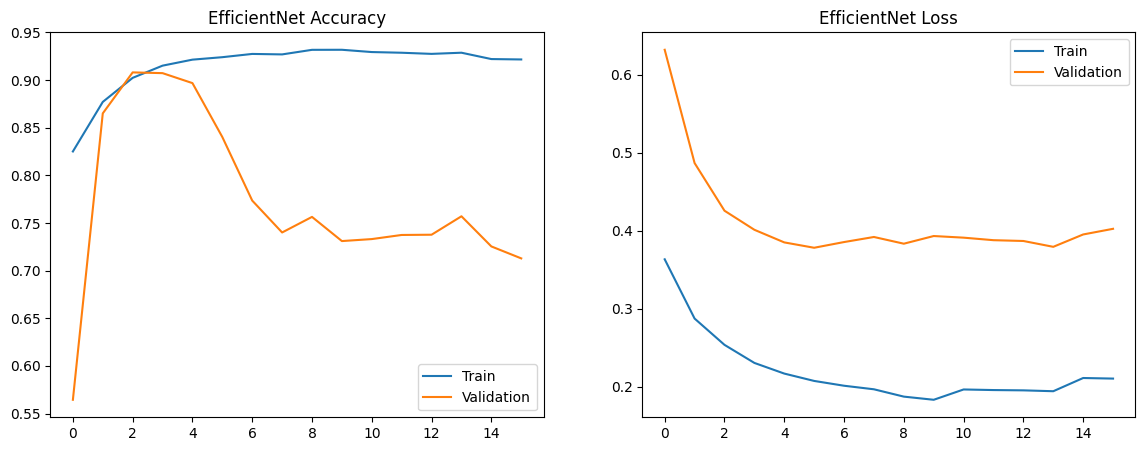

In [36]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history_efficient.history["accuracy"])
plt.plot(history_efficient.history["val_accuracy"])

plt.title("EfficientNet Accuracy")

plt.legend(["Train","Validation"])


plt.subplot(1,2,2)

plt.plot(history_efficient.history["loss"])
plt.plot(history_efficient.history["val_loss"])

plt.title("EfficientNet Loss")

plt.legend(["Train","Validation"])

plt.show()

In [37]:
# ==========================================================
# CELL 37
# EfficientNetB0 Prediction
# ==========================================================

start = time.time()
y_prob = efficientnet_model.predict(test_ds, verbose=0).ravel()
inference_time = time.time() - start
y_pred = (y_prob >= 0.5).astype(int)

print("EfficientNetB0 prediction completed")
print("Inference Time:", round(inference_time, 4), "sec")


EfficientNetB0 prediction completed
Inference Time: 12.2355 sec


**Reading:** ResNet50 is more balanced than VGG16 at threshold 0.5, but remains below the plain CNN on Macro-F1 and is much larger.


In [38]:
# ==========================================================
# CELL 38
# EfficientNetB0 Performance Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

display(pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score",
                                         "Macro F1", "Weighted F1", "ROC AUC", "PR AUC"],
                      "Value": [accuracy, precision, recall, f1, f1_macro,
                                f1_weighted, auc, pr_auc]}))


,Metric,Value
0,Accuracy,0.849159
1,Precision,0.977333
2,Recall,0.622775
3,F1 Score,0.760771
4,Macro F1,0.825313
5,Weighted F1,0.840142
6,ROC AUC,0.967016
7,PR AUC,0.948593


In [39]:
# ==========================================================
# CELL 39
# Classification Report
# ==========================================================

print(

classification_report(

    y_test,
    y_pred,
    digits=4

)

)

              precision    recall  f1-score   support

           0     0.8075    0.9910    0.8899      4753
           1     0.9773    0.6228    0.7608      2977

    accuracy                         0.8492      7730
   macro avg     0.8924    0.8069    0.8253      7730
weighted avg     0.8729    0.8492    0.8401      7730



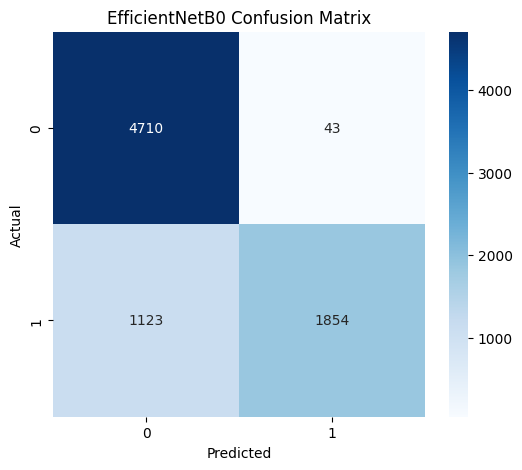

In [40]:
# ==========================================================
# CELL 40
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("EfficientNetB0 Confusion Matrix")

plt.show()

In [41]:
# ==========================================================
# CELL 41
# EfficientNetB0 Model Information (actual saved size)
# ==========================================================

parameters = efficientnet_model.count_params()
_size_path = "_efficientnet_size_check.keras"
efficientnet_model.save(_size_path, overwrite=True)
size_mb = os.path.getsize(_size_path) / (1024 ** 2)
os.remove(_size_path)

print("Parameters:", format(parameters, ","))
print("Training Time:", round(training_time_efficient, 2), "sec")
print("Inference Time:", round(inference_time, 4), "sec")
print("Actual Model Size:", round(size_mb, 2), "MB")


Parameters: 4,050,852
Training Time: 484.86 sec
Inference Time: 12.2355 sec
Actual Model Size: 16.27 MB


**Reading:** EfficientNetB0 has high malware precision but low recall, so many malware samples are missed; accuracy alone would hide this weakness.


In [42]:
accuracy_efficient = accuracy
precision_efficient = precision
recall_efficient = recall
f1_efficient = f1
f1_macro_efficient = f1_macro
f1_weighted_efficient = f1_weighted
auc_efficient = auc
pr_auc_efficient = pr_auc
inference_time_efficient = inference_time
parameters_efficient = parameters
size_mb_efficient = size_mb

y_prob_efficient = y_prob.copy()
y_pred_efficient = y_pred.copy()


In [43]:
comparison = pd.DataFrame({
    "Model": ["VGG16", "ResNet50", "EfficientNetB0"],
    "Accuracy": [accuracy_vgg, accuracy_resnet, accuracy_efficient],
    "Precision": [precision_vgg, precision_resnet, precision_efficient],
    "Recall": [recall_vgg, recall_resnet, recall_efficient],
    "F1 Score": [f1_vgg, f1_resnet, f1_efficient],
    "Macro F1": [f1_macro_vgg, f1_macro_resnet, f1_macro_efficient],
    "Weighted F1": [f1_weighted_vgg, f1_weighted_resnet, f1_weighted_efficient],
    "ROC AUC": [auc_vgg, auc_resnet, auc_efficient],
    "PR AUC": [pr_auc_vgg, pr_auc_resnet, pr_auc_efficient],
    "Training Time (sec)": [training_time_vgg, training_time_resnet,
                            training_time_efficient],
    "Inference Time (sec)": [inference_time_vgg, inference_time_resnet,
                             inference_time_efficient],
    "Parameters": [parameters_vgg, parameters_resnet, parameters_efficient],
    "Model Size (MB)": [size_mb_vgg, size_mb_resnet, size_mb_efficient]
})

display(comparison.sort_values("Macro F1", ascending=False).reset_index(drop=True))


,Model,Accuracy,Precision,Recall,F1 Score,Macro F1,Weighted F1,ROC AUC,PR AUC,Training Time (sec),Inference Time (sec),Parameters,Model Size (MB)
0,ResNet50,0.924709,0.854395,0.969768,0.908433,0.922253,0.925428,0.987535,0.982228,458.777323,12.636708,24112513,96.621502
1,VGG16,0.900906,0.797257,0.995969,0.885603,0.899100,0.902201,0.994977,0.992493,519.975482,6.281444,14846273,57.732219
2,EfficientNetB0,0.849159,0.977333,0.622775,0.760771,0.825313,0.840142,0.967016,0.948593,484.860470,12.235482,4050852,16.269617


In [44]:
# ==========================================================
# BASELINE 4 — Custom CNN Without Attention
# Matched control for the proposed CNN + CBAM
# ==========================================================

def build_plain_cnn(input_shape=(96, 96, 3)):
    inputs = Input(shape=input_shape, name="input")
    x = Rescaling(1.0 / 255.0, name="rescale")(inputs)

    for block, filters in enumerate([32, 64, 128], start=1):
        x = Conv2D(filters, 3, padding="same", use_bias=False,
                   name=f"conv{block}")(x)
        x = BatchNormalization(name=f"bn{block}")(x)
        x = Activation("relu", name=f"relu{block}")(x)
        if block >= 2:
            x = Dropout(0.30, name=f"drop{block}")(x)
        x = MaxPooling2D(2, name=f"pool{block}")(x)

    x = Conv2D(256, 3, padding="same", use_bias=False, name="conv4")(x)
    x = BatchNormalization(name="bn4")(x)
    x = Activation("relu", name="relu4")(x)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(256, use_bias=False, name="dense1")(x)
    x = BatchNormalization(name="bn_dense1")(x)
    x = Activation("relu", name="relu_dense1")(x)
    x = Dropout(0.50, name="drop_dense1")(x)
    x = Dense(128, use_bias=False, name="dense2")(x)
    x = BatchNormalization(name="bn_dense2")(x)
    x = Activation("relu", name="relu_dense2")(x)
    x = Dropout(0.40, name="drop_dense2")(x)
    outputs = Dense(1, activation="sigmoid", name="output")(x)
    return Model(inputs, outputs, name="Plain_CNN_No_Attention")


with strategy.scope():
    plain_cnn_model = build_plain_cnn((IMG_SIZE, IMG_SIZE, 3))

plain_cnn_model.summary()


Model: "Plain_CNN_No_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 96, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 48, 48, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 24, 24, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense1 (Activation)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense1 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,76

 Total params: 489,825 (1.87 MB)

 Trainable params: 488,097 (1.86 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [45]:
# Compile the matched no-attention CNN.
with strategy.scope():
    plain_cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        run_eagerly=False,
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )


In [46]:
# Train for at most 60 epochs; early stopping restores the best weights.
start_train = time.time()
history_plain = plain_cnn_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("plain_cnn"),
    verbose=1
)
training_time_plain = time.time() - start_train

print("Plain CNN training finished")
print("Configured maximum epochs:", EPOCHS)
print("Epochs actually completed:", len(history_plain.history["loss"]))
print("Training time:", round(training_time_plain, 2), "sec")


Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 20 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1787877091.943497      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Plain_CNN_No_Attention_1/drop2_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1126/1126 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.9557 - auc: 0.9878 - loss: 0.1335 - precision: 0.9288 - recall: 0.9589 - val_accuracy: 0.7010 - val_auc: 0.9894 - val_loss: 0.3483 - val_precision: 0.9830 - val_recall: 0.2181 - learning_rate: 0.0010
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.9438 - auc: 0.9829 - loss: 0.1639 - precision: 0.9015 - recall: 0.9595 - val_accuracy: 0.6198 - val_auc: 0.9872 - val_loss: 1.3397 - val_precision: 1.0000 - val_recall: 0.0010 - learning_rate: 0.0010
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.9472 - auc: 0.9854 - loss: 0.1509 - precision: 0.9047 - recall: 0.9650 - val_accuracy: 0.6751 - val_auc: 0.9928 - val_loss: 0.3860 - val_precision: 1.0000 - val_recall: 0.1463 - learning_rate: 0.0010
Epoch 4/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.9493 - auc: 0.9861 - loss: 0.1478 - precision: 0.9070 - recall: 0.9680 - val_accuracy: 0.9120 - val_auc: 0.9889 - val_loss: 0.2241 

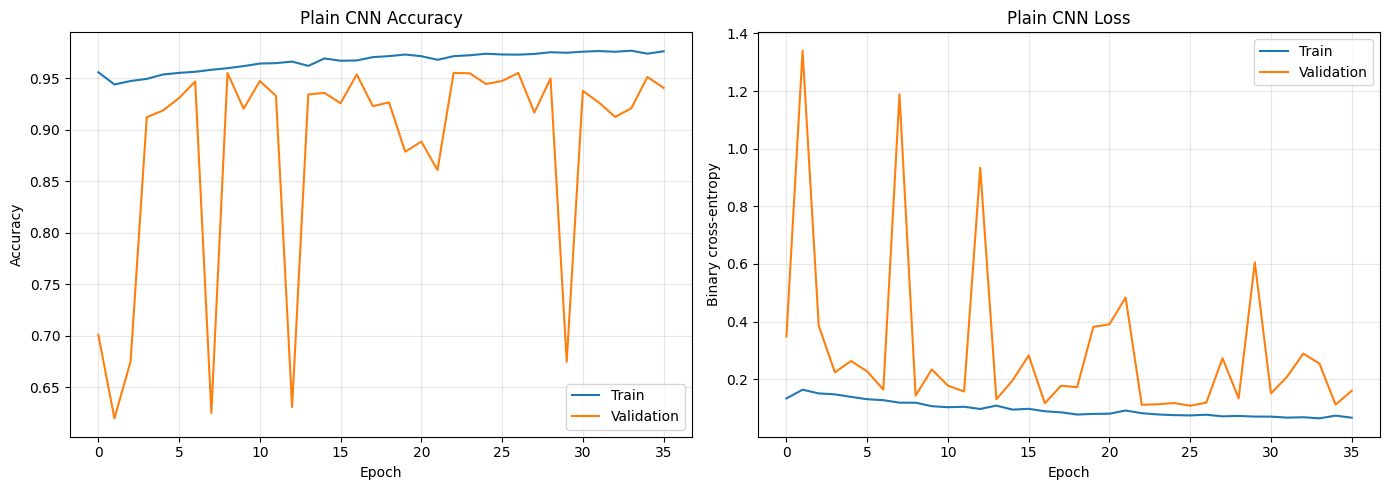

Reading: compare train and validation curves for convergence and overfitting.


In [47]:
# Plain CNN training curves.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_plain.history["accuracy"], label="Train")
axes[0].plot(history_plain.history["val_accuracy"], label="Validation")
axes[0].set_title("Plain CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_plain.history["loss"], label="Train")
axes[1].plot(history_plain.history["val_loss"], label="Validation")
axes[1].set_title("Plain CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary cross-entropy")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Reading: compare train and validation curves for convergence and overfitting.")


In [48]:
# Plain CNN test evaluation.
start = time.time()
y_prob_plain = plain_cnn_model.predict(test_ds, verbose=0).ravel()
inference_time_plain = time.time() - start
y_pred_plain = (y_prob_plain >= 0.5).astype(int)

accuracy_plain = accuracy_score(y_test, y_pred_plain)
precision_plain = precision_score(y_test, y_pred_plain, zero_division=0)
recall_plain = recall_score(y_test, y_pred_plain, zero_division=0)
f1_plain = f1_score(y_test, y_pred_plain, zero_division=0)
f1_macro_plain = f1_score(y_test, y_pred_plain, average="macro", zero_division=0)
f1_weighted_plain = f1_score(
    y_test, y_pred_plain, average="weighted", zero_division=0
)
auc_plain = roc_auc_score(y_test, y_prob_plain)
pr_auc_plain = average_precision_score(y_test, y_prob_plain)

print(classification_report(y_test, y_pred_plain, digits=4, zero_division=0))
display(pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Macro F1",
               "Weighted F1", "ROC AUC", "PR AUC"],
    "Value": [accuracy_plain, precision_plain, recall_plain, f1_plain,
              f1_macro_plain, f1_weighted_plain, auc_plain, pr_auc_plain]
}))


              precision    recall  f1-score   support

           0     0.9631    0.9567    0.9599      4753
           1     0.9315    0.9416    0.9365      2977

    accuracy                         0.9508      7730
   macro avg     0.9473    0.9491    0.9482      7730
weighted avg     0.9510    0.9508    0.9509      7730



,Metric,Value
0,Accuracy,0.950841
1,Precision,0.931539
2,Recall,0.941552
3,F1 Score,0.936519
4,Macro F1,0.948204
5,Weighted F1,0.950889
6,ROC AUC,0.993128
7,PR AUC,0.987037


In [49]:
# Plain CNN model information.
parameters_plain = plain_cnn_model.count_params()
_size_path = "_plain_cnn_size_check.keras"
plain_cnn_model.save(_size_path, overwrite=True)
size_mb_plain = os.path.getsize(_size_path) / (1024 ** 2)
os.remove(_size_path)

print("Parameters:", f"{parameters_plain:,}")
print("Training Time:", round(training_time_plain, 2), "sec")
print("Inference Time:", round(inference_time_plain, 4), "sec")
print("Actual Model Size:", round(size_mb_plain, 2), "MB")


Parameters: 489,825
Training Time: 1213.34 sec
Inference Time: 4.5558 sec
Actual Model Size: 5.7 MB


,Model,Accuracy,Precision,Recall,F1 Score,Macro F1,Weighted F1,ROC AUC,PR AUC,Training Time (sec),Inference Time (sec),Parameters,Model Size (MB)
0,Plain CNN (No Attention),0.950841,0.931539,0.941552,0.936519,0.948204,0.950889,0.993128,0.987037,1213.343407,4.555825,489825,5.704069
1,ResNet50,0.924709,0.854395,0.969768,0.908433,0.922253,0.925428,0.987535,0.982228,458.777323,12.636708,24112513,96.621502
2,VGG16,0.900906,0.797257,0.995969,0.885603,0.899100,0.902201,0.994977,0.992493,519.975482,6.281444,14846273,57.732219
3,EfficientNetB0,0.849159,0.977333,0.622775,0.760771,0.825313,0.840142,0.967016,0.948593,484.860470,12.235482,4050852,16.269617


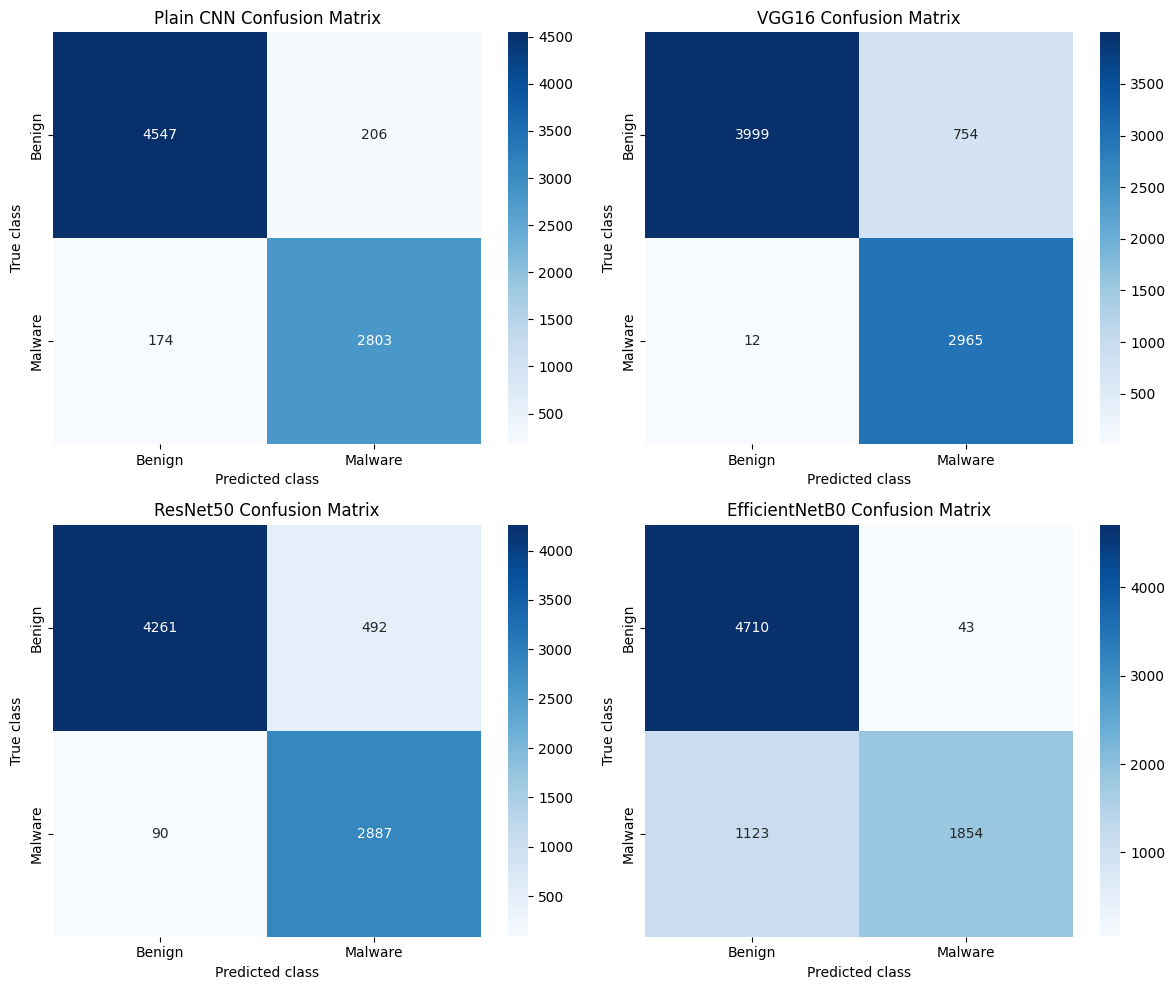

Reading: diagonal cells are correct predictions; FN malware errors are critical.


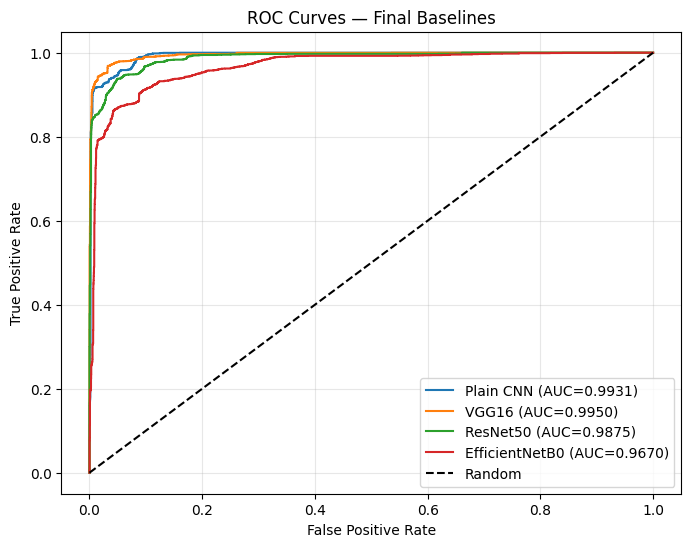

Reading: curves closer to the top-left indicate better class separation.


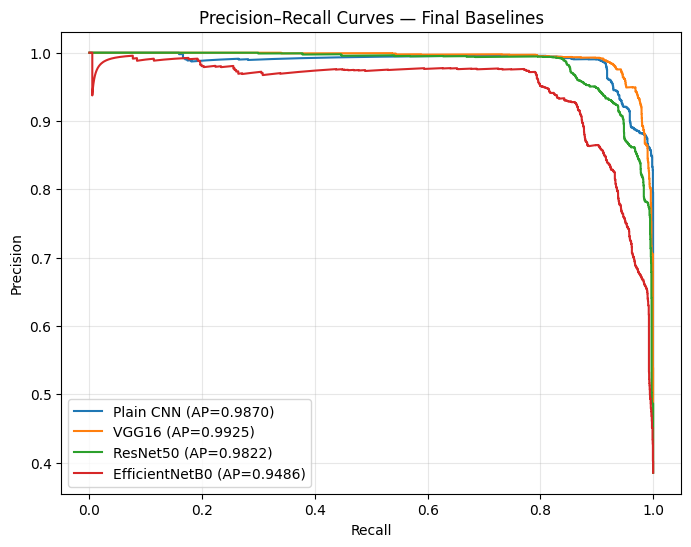

Reading: higher curves indicate a better precision–recall trade-off for malware.


In [50]:
# ==========================================================
# Final Four-Baseline Comparison + Required Curves
# ==========================================================

comparison = pd.DataFrame({
    "Model": ["Plain CNN (No Attention)", "VGG16", "ResNet50", "EfficientNetB0"],
    "Accuracy": [accuracy_plain, accuracy_vgg, accuracy_resnet, accuracy_efficient],
    "Precision": [precision_plain, precision_vgg, precision_resnet, precision_efficient],
    "Recall": [recall_plain, recall_vgg, recall_resnet, recall_efficient],
    "F1 Score": [f1_plain, f1_vgg, f1_resnet, f1_efficient],
    "Macro F1": [f1_macro_plain, f1_macro_vgg, f1_macro_resnet, f1_macro_efficient],
    "Weighted F1": [f1_weighted_plain, f1_weighted_vgg,
                    f1_weighted_resnet, f1_weighted_efficient],
    "ROC AUC": [auc_plain, auc_vgg, auc_resnet, auc_efficient],
    "PR AUC": [pr_auc_plain, pr_auc_vgg, pr_auc_resnet, pr_auc_efficient],
    "Training Time (sec)": [training_time_plain, training_time_vgg,
                            training_time_resnet, training_time_efficient],
    "Inference Time (sec)": [inference_time_plain, inference_time_vgg,
                             inference_time_resnet, inference_time_efficient],
    "Parameters": [parameters_plain, parameters_vgg,
                   parameters_resnet, parameters_efficient],
    "Model Size (MB)": [size_mb_plain, size_mb_vgg,
                        size_mb_resnet, size_mb_efficient]
})
display(comparison.sort_values("Macro F1", ascending=False).reset_index(drop=True))

model_predictions = {
    "Plain CNN": (y_prob_plain, y_pred_plain),
    "VGG16": (y_prob_vgg, y_pred_vgg),
    "ResNet50": (y_prob_resnet, y_pred_resnet),
    "EfficientNetB0": (y_prob_efficient, y_pred_efficient)
}

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (_, pred)) in zip(axes.flat, model_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malware"],
                yticklabels=["Benign", "Malware"])
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
plt.tight_layout()
plt.show()
print("Reading: diagonal cells are correct predictions; FN malware errors are critical.")

# ROC curves
plt.figure(figsize=(8, 6))
for name, (prob, _) in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves — Final Baselines")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Reading: curves closer to the top-left indicate better class separation.")

# Precision-recall curves
plt.figure(figsize=(8, 6))
for name, (prob, _) in model_predictions.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall_curve, precision_curve, label=f"{name} (AP={ap:.4f})")
plt.title("Precision–Recall Curves — Final Baselines")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Reading: higher curves indicate a better precision–recall trade-off for malware.")


## Baseline conclusion

The **plain CNN** is the best baseline by the primary Macro-F1 metric
(0.948204) and accuracy (0.950841). VGG16 has the highest malware recall
(0.995969) but substantially lower precision, while EfficientNetB0 misses many malware
samples. The plain CNN is therefore the matched comparator for the Task 2 attention
model and the no-attention control used in Task 3.
